# Task 2.1 — Toy Dataset Generation for MKL Experiments

**Paper**: Gönen, M. & Alpaydın, E. (2011). *Multiple Kernel Learning Algorithms*. JMLR, 12, 2211–2268.

---

## Objective
Generate a synthetic 2-class, 2-feature dataset that exhibits non-linear class boundaries, making it a meaningful testbed for Multiple Kernel Learning.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os

# Ensure results directory exists
os.makedirs('results', exist_ok=True)
os.makedirs('data', exist_ok=True)

# ──────────────────────────────────────────
# Configuration
# ──────────────────────────────────────────
SEED = 42
N_SAMPLES = 200
N_FEATURES = 2
N_INFORMATIVE = 2
N_REDUNDANT = 0
N_CLUSTERS_PER_CLASS = 2  # key for non-linearity
TEST_SIZE = 0.2

np.random.seed(SEED)

### Dataset Generation
We use `make_classification` with **2 clusters per class** to ensure the decision boundary is non-linear. This is critical because a single linear kernel cannot perfectly separate these clusters, but an RBF kernel can capture the local structure. MKL should benefit by combining both views.

In [2]:
X, y = make_classification(
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    n_informative=N_INFORMATIVE,
    n_redundant=N_REDUNDANT,
    n_clusters_per_class=N_CLUSTERS_PER_CLASS,
    class_sep=1.0,
    flip_y=0.05,
    random_state=SEED
)

print(f"Dataset shape: X={X.shape}, y={y.shape}")
print(f"Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}")

Dataset shape: X=(200, 2), y=(200,)
Class distribution: {np.int64(0): np.int64(104), np.int64(1): np.int64(96)}


### Preprocessing — Standard Scaling
Kernel functions (especially RBF) are sensitive to feature scales. We apply `StandardScaler` to ensure zero mean and unit variance across both features, which prevents one feature from dominating the kernel computation. The scaler is fitted **only on training data** and then applied to test data to avoid data leakage.

In [3]:
# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

# Standard scaling (fit on train only)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"Train mean: {X_train.mean(axis=0).round(4)}, std: {X_train.std(axis=0).round(4)}")

Train: 160 samples | Test: 40 samples
Train mean: [ 0. -0.], std: [1. 1.]


### Save Dataset for Downstream Notebooks
We persist the processed splits so that Tasks 2.2, 2.3, 3.1, and 3.2 can load the exact same data without re-generating.

In [4]:
np.savez('data/toy_dataset.npz',
         X_train=X_train, X_test=X_test,
         y_train=y_train, y_test=y_test)
print("Saved to data/toy_dataset.npz")

Saved to data/toy_dataset.npz


### Dataset Visualisation
We plot the 2D feature space with class colours to visually confirm the non-linear decision boundary.

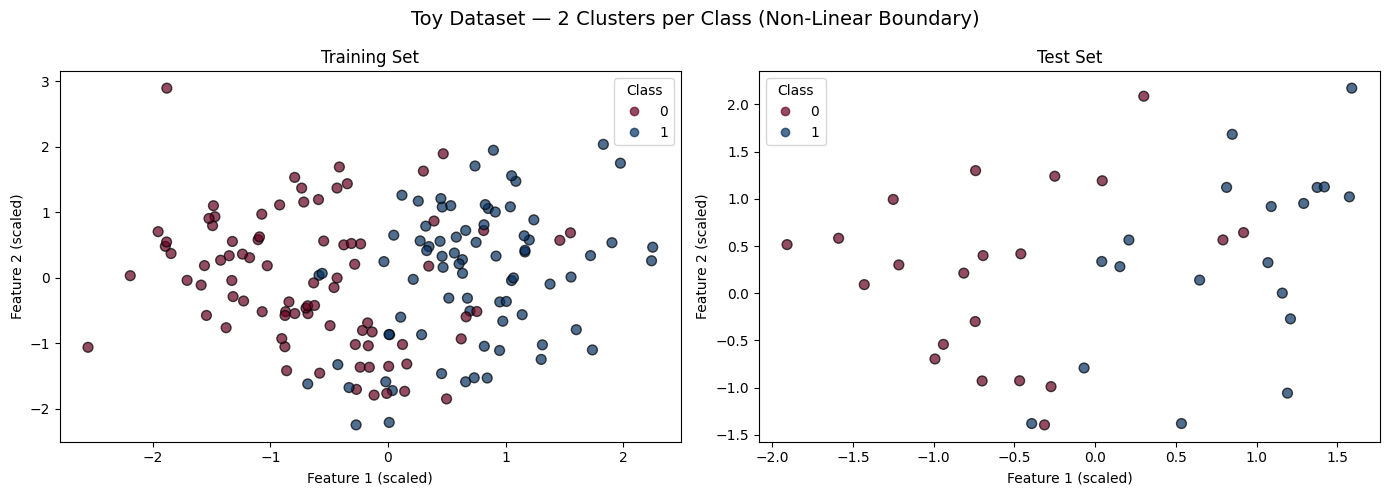

Plot saved to results/task_2_1_dataset.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (X_part, y_part, title) in zip(axes, [
    (X_train, y_train, 'Training Set'),
    (X_test, y_test, 'Test Set')
]):
    scatter = ax.scatter(X_part[:, 0], X_part[:, 1], c=y_part,
                         cmap='RdBu', edgecolors='k', alpha=0.7, s=50)
    ax.set_xlabel('Feature 1 (scaled)')
    ax.set_ylabel('Feature 2 (scaled)')
    ax.set_title(title)
    ax.legend(*scatter.legend_elements(), title='Class')

plt.suptitle('Toy Dataset — 2 Clusters per Class (Non-Linear Boundary)', fontsize=14)
plt.tight_layout()
plt.savefig('results/task_2_1_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to results/task_2_1_dataset.png")

## Why This Dataset Is a Good Testbed for MKL

1. **Non-linear boundary**: With 2 clusters per class, the optimal decision boundary is non-linear. A single linear kernel will underperform, while an RBF kernel can capture the local cluster structure. MKL, by combining both kernels, can exploit the global linear trend *and* local non-linear structure simultaneously — exactly the scenario where kernel combination is theoretically advantageous (Gönen & Alpaydın, 2011, Section 1).

2. **Low dimensionality (2D)**: Two features allow clear 2D visualisation of decision boundaries, making it straightforward to inspect and compare how different kernel strategies partition the feature space.

3. **Controlled noise**: A small label flip rate (`flip_y=0.05`) introduces realistic noise without overwhelming the signal, allowing us to test the robustness of MKL's kernel weighting.

4. **Sufficient size (200 samples)**: Meets the ≥100 sample requirement while remaining fast to train on CPU.